In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-25 10:42:12.278359


# Create AnnData from Xenium output folders

In [2]:
import sys
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
import math
import session_info

In [3]:
plt.rcParams['figure.dpi'] = 150

## Set paths

In [4]:
data_input_folder = '/home/workspace/projects/drg/download/isolon' # where current data is

base_dir = '/home/workspace/projects/drg' 
fig_dir = os.path.join(base_dir, 'figures/qc/') # where to save qc viz
h5ad_dir = os.path.join(base_dir, 'data/h5ad/export_01/01_raw/output_folder') # where to save anndata
metadata_dir = os.path.join(base_dir, 'metadata')

os.makedirs(base_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(h5ad_dir, exist_ok=True)
os.makedirs(metadata_dir, exist_ok=True)


In [5]:
sample_id_mapping = {
    "output-XETG00123__0052046__TMA00307__20251119__221941": "TMA00307",
    "output-XETG00123__0052399__TMA00308__20251119__221941": "TMA00308",
    "output-XETG00123__0052046__TMA00311__20251119__221941": "TMA00311",
}

## Functions

In [6]:
def h5_to_adata(directory, sample_id):
    # File names    
    h5_file = os.path.join(directory, 'cell_feature_matrix.h5')
    cells_file = os.path.join(directory, 'cells.csv.gz')

    # h5 to adata
    adata = sc.read_10x_h5(
        filename=h5_file
    )

    # cells file
    df = pd.read_csv(
        cells_file, 
        compression='gzip'
    )

    # Set index
    df.set_index(adata.obs_names, inplace=True)
    adata.obs = df.copy()

    # x, y coordinates
    adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

    # Add sample metadata
    adata.obs['output_id'] = sample_id

    return adata

## Create sample dictionary

In [7]:
directory_to_sample = {
    os.path.join(data_input_folder, subdir): f"{subdir}"
    for subdir in os.listdir(data_input_folder) if os.path.isdir(os.path.join(data_input_folder, subdir))
    if os.path.isdir(os.path.join(data_input_folder, subdir)) and not subdir.startswith(".")  # Excludes hidden folders like .ipynb_checkpoints
}

print(directory_to_sample)

{'/home/workspace/projects/drg/download/isolon/output-XETG00123__0052399__TMA00308__20251119__221941': 'output-XETG00123__0052399__TMA00308__20251119__221941', '/home/workspace/projects/drg/download/isolon/output-XETG00123__0052046__TMA00311__20251119__221941': 'output-XETG00123__0052046__TMA00311__20251119__221941', '/home/workspace/projects/drg/download/isolon/output-XETG00123__0052046__TMA00307__20251119__221941': 'output-XETG00123__0052046__TMA00307__20251119__221941'}


## Create anndata

In [8]:
# Loop through each key-value pair in the dictionary
adata_list = []
for directory, xenium_run_id in directory_to_sample.items():
    print(f"Processing: {directory} -> Run ID: {xenium_run_id}")
    adata = h5_to_adata(directory, xenium_run_id)
    adata.obs["xenium_run_id"] = xenium_run_id  
    adata_list.append(adata)

Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0052399__TMA00308__20251119__221941 -> Run ID: output-XETG00123__0052399__TMA00308__20251119__221941
Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0052046__TMA00311__20251119__221941 -> Run ID: output-XETG00123__0052046__TMA00311__20251119__221941
Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0052046__TMA00307__20251119__221941 -> Run ID: output-XETG00123__0052046__TMA00307__20251119__221941


In [9]:
# Annotate sample ID based on xenium output folder name

sample_id_mapping =  sample_id_mapping

# Apply the mapping to adata.obs["xenium_run_id"]
for adata in adata_list:
    adata.obs["output_id"] = adata.obs["xenium_run_id"].map(sample_id_mapping)
    print(adata.obs[["xenium_run_id", "output_id"]].head(3))

                                                xenium_run_id output_id
aaabcimg-1  output-XETG00123__0052399__TMA00308__20251119_...  TMA00308
aaabcncn-1  output-XETG00123__0052399__TMA00308__20251119_...  TMA00308
aaaiofaj-1  output-XETG00123__0052399__TMA00308__20251119_...  TMA00308
                                                xenium_run_id output_id
aaabeogo-1  output-XETG00123__0052046__TMA00311__20251119_...  TMA00311
aaacfmdl-1  output-XETG00123__0052046__TMA00311__20251119_...  TMA00311
aaachkic-1  output-XETG00123__0052046__TMA00311__20251119_...  TMA00311
                                                xenium_run_id output_id
aabdcfle-1  output-XETG00123__0052046__TMA00307__20251119_...  TMA00307
aabkmpon-1  output-XETG00123__0052046__TMA00307__20251119_...  TMA00307
aacdlbke-1  output-XETG00123__0052046__TMA00307__20251119_...  TMA00307


## QC

In [10]:
adata_list

[AnnData object with n_obs × n_vars = 9759 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 24803 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 9238 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 

#### Fix order

In [11]:
#desired_order = ["TIS09471_Control", "TIS09474_Trpv1+"]

#adata_list = sorted(adata_list, key=lambda ad: desired_order.index(ad.obs['output_id'].iloc[0]))

#### Visualize

TMA00308
9759 cells
TMA00311
24803 cells
TMA00307
9238 cells


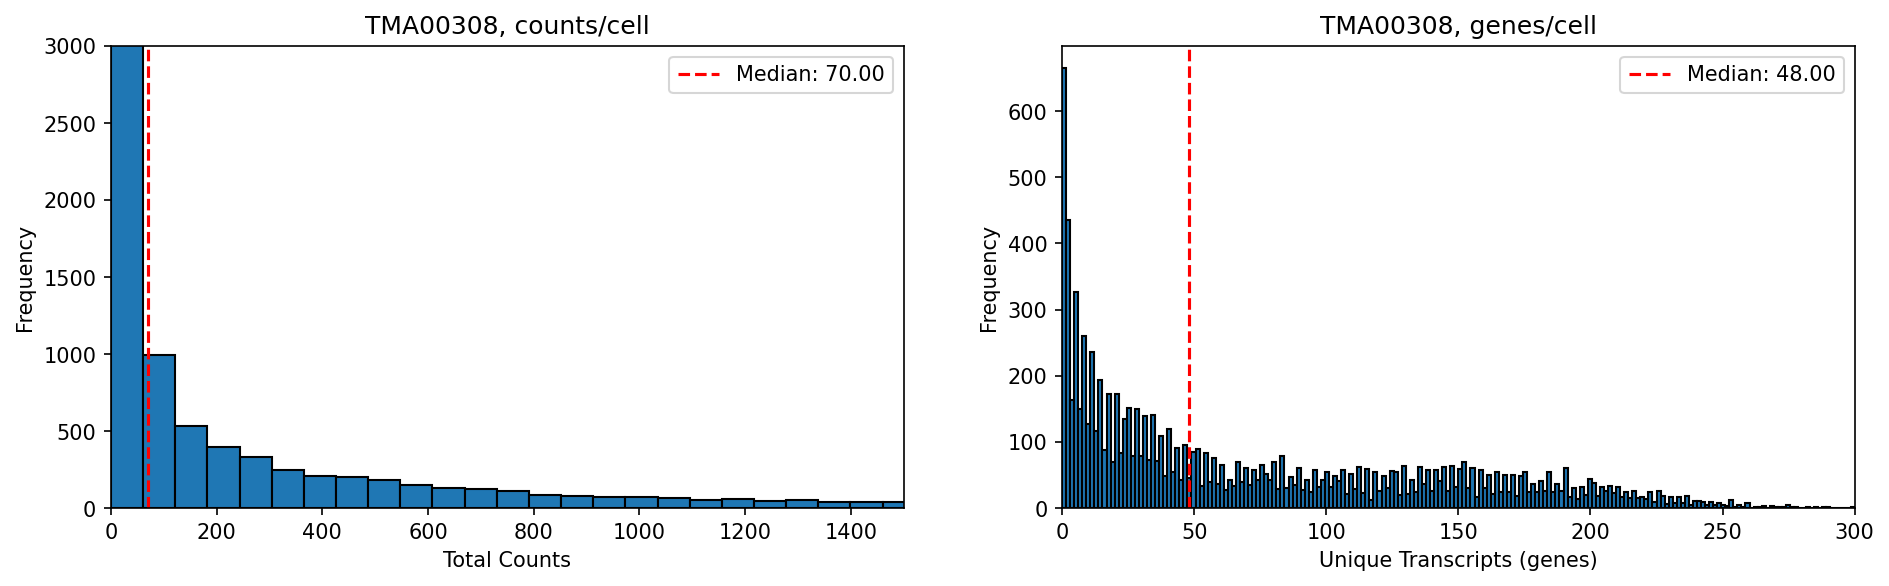

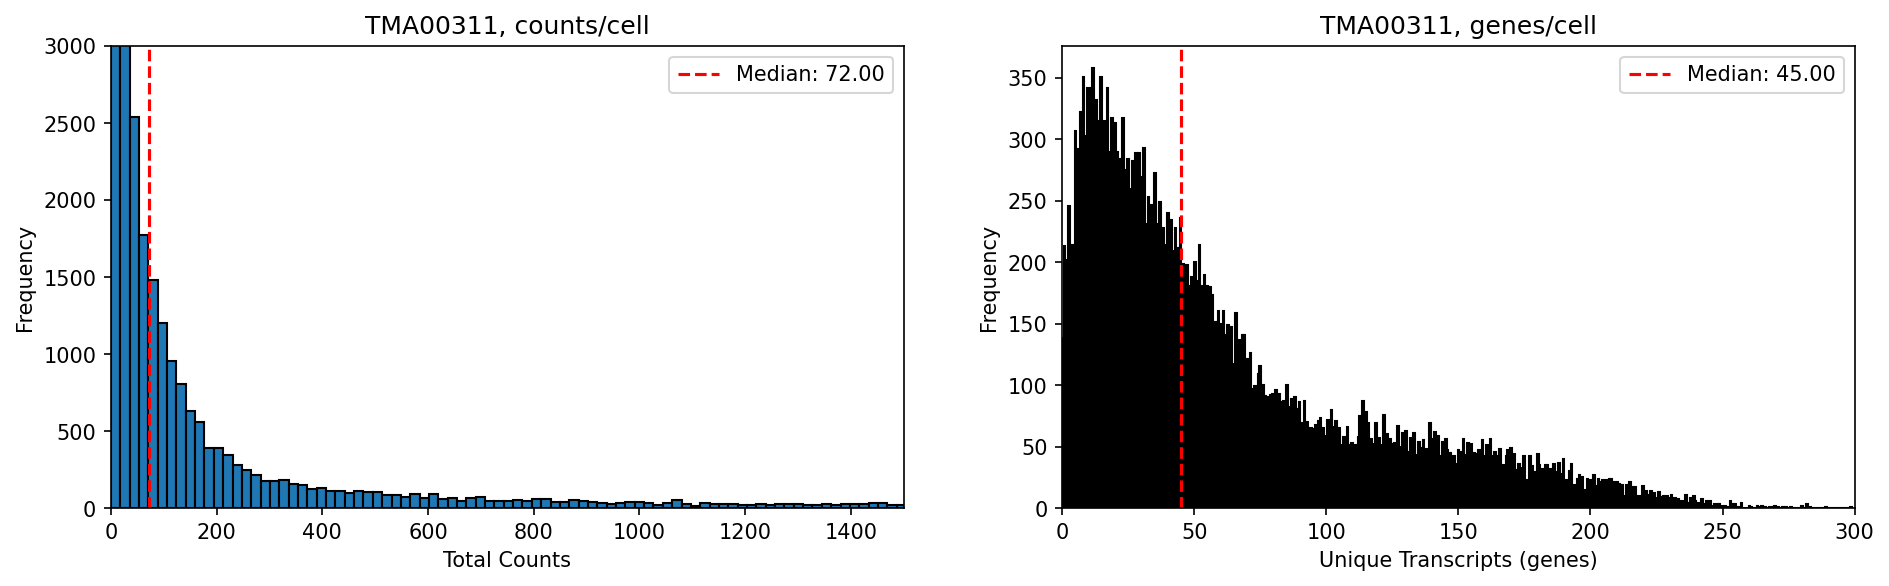

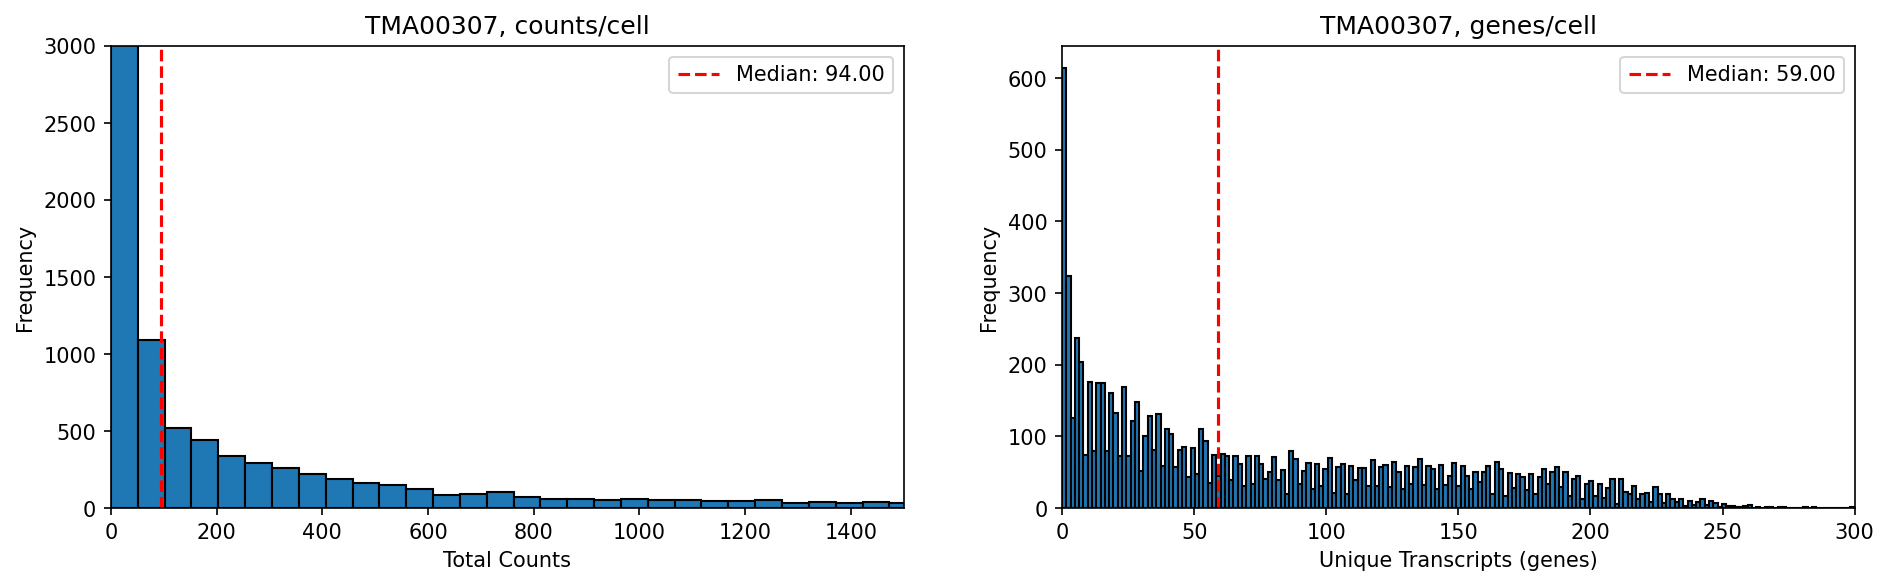

In [12]:
for adata in adata_list:
    sample_id = adata.obs['output_id'].iloc[0]
    print(sample_id)

    # Calculate QC
    sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

    # Number of cells
    cell_num = adata.obs.shape[0]
    print(cell_num, 'cells')

    # Visualize QC
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))

    # Plot the first histogram: Total Counts
    counts_median = adata.obs["total_counts"].median()  
    axs[0].hist(adata.obs["total_counts"], bins=math.ceil(cell_num / 50), edgecolor='black')
    axs[0].set_title(sample_id + ", " + "counts/cell")
    axs[0].set_xlim(0, 1500)
    axs[0].set_ylim(0, 3000)
    axs[0].set_xlabel('Total Counts')
    axs[0].set_ylabel('Frequency')
    axs[0].axvline(counts_median, color='red', linestyle='--', label=f'Median: {counts_median:.2f}')  # Add vertical line
    axs[0].legend()  # Add legend for the median line

    # Plot the second histogram: Genes by Counts
    genes_median = adata.obs["n_genes_by_counts"].median()  
    axs[1].hist(adata.obs["n_genes_by_counts"], bins=math.ceil(cell_num / 50), edgecolor='black')
    axs[1].set_title(sample_id + ", " + "genes/cell")
    axs[1].set_xlim(0, 300)
    axs[1].set_xlabel('Unique Transcripts (genes)')
    axs[1].set_ylabel('Frequency')
    axs[1].axvline(genes_median, color='red', linestyle='--', label=f'Median: {genes_median:.2f}')  # Add vertical line
    axs[1].legend()  # Add legend for the median line

    # Save figure
    fig.savefig(os.path.join(fig_dir, sample_id + '_raw_QC.png'))

In [13]:
#for adata in adata_list:
#    sc.pl.violin(adata, ['total_counts', 'n_genes_by_counts'])

TMA00308


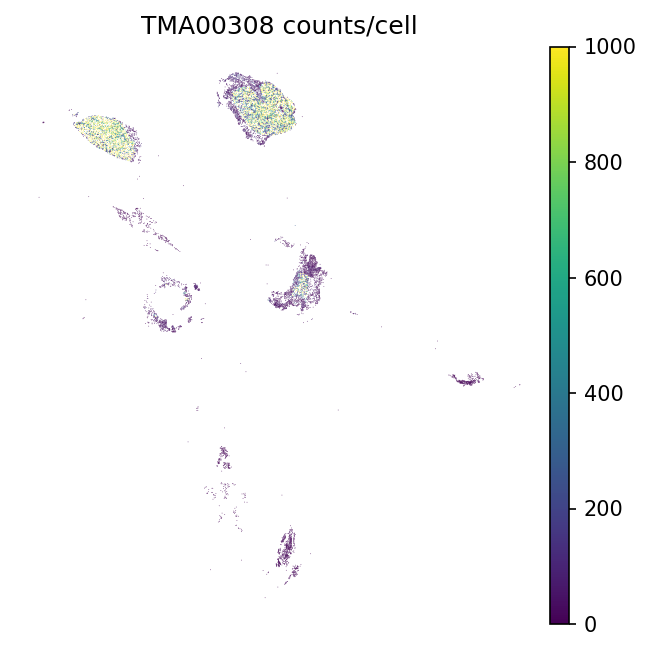

TMA00311


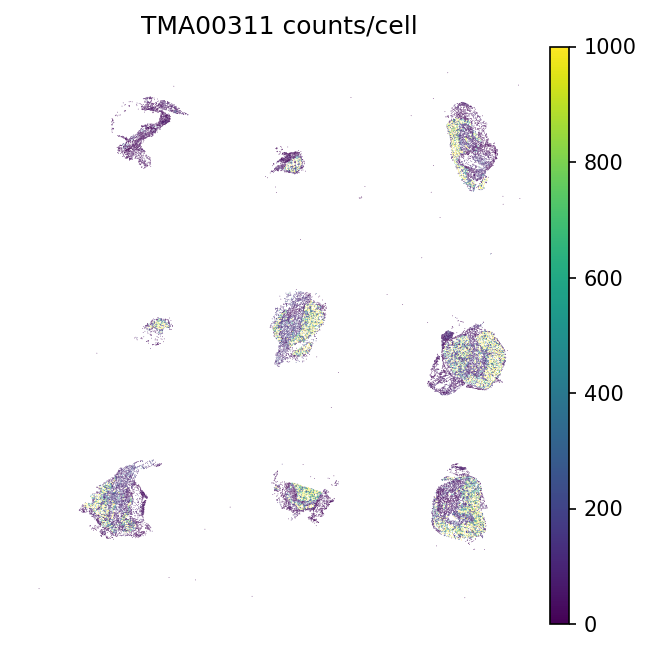

TMA00307


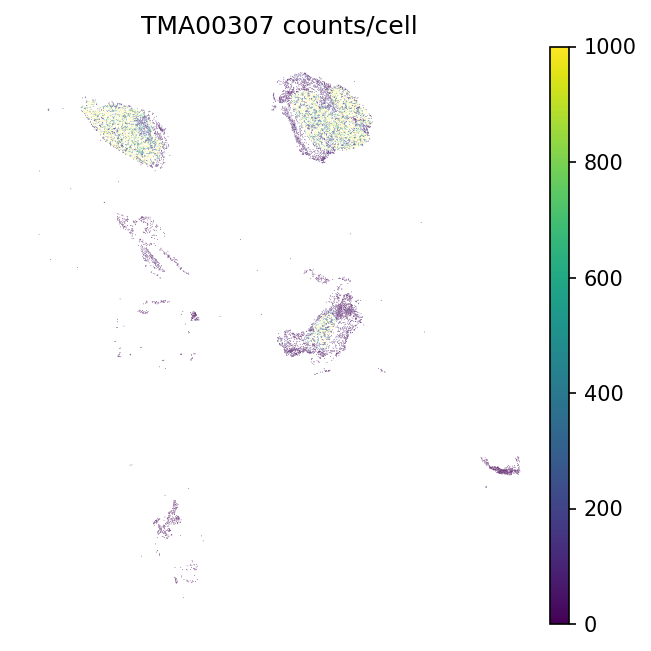

In [14]:
# spatial qc

for adata in adata_list:
    sample_id = adata.obs['output_id'].iloc[0]
    print(sample_id)

    fig, ax = plt.subplots(figsize=(5, 5))
    sc.pl.embedding(adata, basis='spatial', color='total_counts', title=sample_id + ' counts/cell',
                    vmin=0, vmax=1000, size=0.5, ax=ax, frameon = False)  # Pass ax explicitly

    fig.savefig(os.path.join(fig_dir, sample_id + '_spatial_QC.png'))
    plt.close(fig)

## Genes of interest

In [15]:
genes = adata.var
genes.head()

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
1500009L16Rik,ENSMUSG00000087651,Gene Expression,Unknown,703,0.110955,0.105220,92.390128,1025.0,6.933423
6330403K07Rik,ENSMUSG00000018451,Gene Expression,Unknown,3233,4.902360,1.775352,65.003247,45288.0,10.720819
Abcb1a,ENSMUSG00000040584,Gene Expression,Unknown,1819,0.563325,0.446815,80.309591,5204.0,8.557375
Ache,ENSMUSG00000023328,Gene Expression,Unknown,2582,1.520242,0.924355,72.050227,14044.0,9.550022
Acta2,ENSMUSG00000035783,Gene Expression,Unknown,341,0.042975,0.042077,96.308725,397.0,5.986452


In [16]:
# save panel
csv_path = os.path.join(metadata_dir, 'gene-panel.csv')
genes.to_csv(csv_path, index = True)

print(f'Gene panel saved at: {csv_path}')

Gene panel saved at: /home/workspace/projects/drg/metadata/gene-panel.csv


In [17]:
#genes_of_interest = ['Epcam', 'Acta2', 'Ptprc',
#                     'Cd19', 'Cd3e', 'Trpv1']

In [18]:
#for adata in adata_list:
#    sample_id = adata.obs['output_id'].iloc[0]
#    print(sample_id)
#    sc.pl.embedding(adata, basis='spatial', color=genes_of_interest,
#                    size=0.5,
#                    ncols=3
#                   ) 

## Export Anndata

In [19]:
for adata in adata_list:
    sample_id = adata.obs['output_id'].iloc[0]
    print(f"Adding raw counts layer for {sample_id} ...")
    adata.layers["raw"] = adata.X.copy()

Adding raw counts layer for TMA00308 ...
Adding raw counts layer for TMA00311 ...
Adding raw counts layer for TMA00307 ...


In [20]:
# export 01

for i, adata in enumerate(adata_list):
    sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
    output_file = os.path.join(h5ad_dir, f"{sample_name}.h5ad")
    
    adata.write(output_file)
    print(f"Saved: {output_file}")

Saved: /home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder/TMA00308.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder/TMA00311.h5ad


/tmp/ipykernel_2053/3662922147.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_2053/3662922147.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_2053/3662922147.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

Saved: /home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder/TMA00307.h5ad


### Session info

In [21]:
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active conda environment: sc-spatial
